In [1]:
import os
import torch
from helper_functions import *
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)

## Checking Device availability

In [3]:
# Checking Device/confirming it works with CUDA

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

x = torch.randn(10000, 10000, device=device)
print("Computation successful on", device)

Using device: cuda
Computation successful on cuda


## Configuration 

In [4]:
# adjust as needed to main path where data is. Should be 'DS6050_Ai_Detection' folder
data_root = Path(r"C:/Users/Jimmy/OneDrive/Desktop/test/DS6050_Ai_Detection")

# train/validate on percent of data. 0.1 = 10%, 1.0 = 100%
train_percent = 0.1

# adjust as needed for training device
batch_size = 16

# workers seem to be bugged, 0 works best
num_workers = 0

learning_rate = 1e-4

# using jpeg compression augmentation during training?
jpeg_compression = True

# number of epochs
num_epochs = 5

# Pick any 4 models: resnet50, vit, resnet50_fft, vit_fft
model_name = 'resnet50' 
# model_name = 'vit'
# model_name = 'resnet50_fft'
# model_name = 'vit_fft'   

# additional name to add at end of model name for logging and pth file
save_model_name = "regular"

make_images = True

# fft helper for dataloading
if 'fft' in model_name:
    fft = True
else:
    fft = False

## Loading Data

In [5]:
train_loader, val_loader, train_dataset, val_dataset, csv_name = main_data_loading(data_root, model_name, train_percent, 
                                                                                   batch_size, num_workers=num_workers, 
                                                                                   jpeg_compression=jpeg_compression)

Using model type: resnet50
Using FFT: False
Original class mapping: {'fake': 0, 'real': 1}
Using 10.0% of the data
Training on 11520 images, validating on 2834 images.
Saved dataset split CSV to: logs/dataset_split_20251206_183228.csv
Total records: 14354


## Confirm Correct Labels for training

In [6]:
confirm_labels(train_dataset, val_dataset)

Confirm correct labels
fake -> 1
real -> 0
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\010956.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\117162.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\real\0033883.png --> Label: 0
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\004497.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\059987.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\validation\fake\011806.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\validation\fake\012341.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\validation\real\0016687.png --> Label: 0
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\validation\real\0023341.png --> Label: 0
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\validation\fake\017221.png --> Label: 1


## Make the desired model

In [7]:
model, criterion, optimizer = make_model(model_name=model_name, learning_rate=learning_rate, device=device)

c:\Users\Jimmy\miniconda3\envs\id_ai\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## Showing JPEG transform

This will show the JPEG transform. Feel free to change the 'index' number to see different images. Will randomly pick a compression amount within the given 'jpeg_q_range'

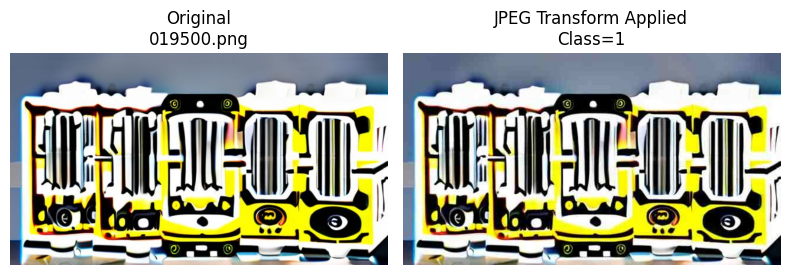

In [8]:
show_jpeg_transform_effect(val_dataset, index = 10, jpeg_q_range=(5, 60)) # range can go from 5 - 95

## Create Grid of Validating Images

Will create grid of n images (n = grid_size * grid_size). In order to load images correctly, needs to know if fft is being run, and what device is being used

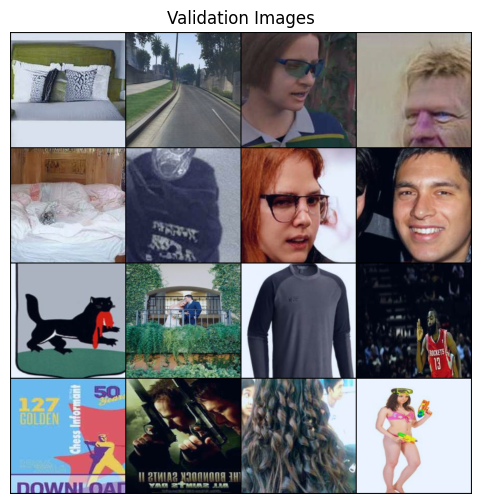

Fake: 010932.png
Fake: 035629.png
Fake: 015110.png
Fake: 020175.png
Fake: 011908.png
Fake: 018999.png
Fake: 002327.png
Fake: 015790.png
Real: 0029849.png
Real: 0002949.png
Real: 0007201.png
Real: 0030285.png
Real: 0030194.png
Real: 0014302.png
Real: 0016811.png
Real: 0020621.png


In [9]:
fixed_images, fixed_labels, grid_size = create_grid_of_val_images(val_dataset, grid_size=4, 
                                                                  fft=fft, device=device, keep=True)

## Main training loop

Will save the model with the best f1 overall score

In [10]:
h = train_model(model=model, train_loader=train_loader, val_loader=val_loader,
                criterion=criterion, optimizer=optimizer, num_epochs=num_epochs,
                batch_size=batch_size, device=device, fft=fft, model_name=model_name, csv_name_used=csv_name,
                model_save_name=save_model_name, make_images=make_images, fixed_images=fixed_images,
                fixed_labels=fixed_labels, grid_size=grid_size)

Using device: cuda (NVIDIA GeForce RTX 4070 Ti)

- Epoch 1/5


Training:   1%|          | 4/720 [00:47<2:23:10, 12.00s/batch, Loss=0.0039, Train Acc=50.00%]


KeyboardInterrupt: 